# PROVA 2 (PRÁTICA) PARADIGMAS DE APRENDIZAGEM DE MÁQUINA

## Nome: Francisco Santana de Sousa Júnior
## Matrícula: 20210025969

### 0. Instalando e importanto bibliotecas necessárias

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 2.4 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.1 MB 2.3 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.1 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.1 MB 2.6 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.1 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 2.9 MB/s eta 0:00:03
   ----------------- ---------------------- 5.0/11.1 MB 3.0 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.1 MB 3.0 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.1 MB 3.0 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.1 MB 3.0 MB/s eta 0:00:02
   ----------

In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFECV 
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


### 1. Pré-processamento de dados

In [2]:
df = pd.read_csv( 'radiomic_data_binary.csv' )
df.shape

(2018, 116)

In [3]:
df.head()

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,class
0,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},245a9a4dd4a20aabe9c478e95a35aa833ca20590,2D,"(1.0, 1.0)",...,0.000038,8.692009,0.962976,0.040777,0.028123,0.000123,8.843847e+06,5.416673,42.367873,BENIGN
1,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},b3a0776528a8f7438a2f6cc95486cafad01adefa,2D,"(1.0, 1.0)",...,0.000021,10.126931,0.963992,0.039417,0.002454,0.000299,4.859019e+07,14.347313,540.091956,BENIGN
2,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},f204a9caa1dea0bd0cfa97a68b8b1b98e9c45054,2D,"(1.0, 1.0)",...,0.000023,9.818248,0.882666,0.167003,0.001089,0.000951,3.526641e+06,0.706177,687.525538,BENIGN
3,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},8e7a5be028d372a7e1729e2bd28bac01c4a00a8b,2D,"(1.0, 1.0)",...,0.000021,9.865219,0.934424,0.078779,0.001812,0.000794,5.654092e+06,1.171521,381.671430,BENIGN
4,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},1e4e7e585f4bfb62c816c1b42c5215a913246ea6,2D,"(1.0, 1.0)",...,0.000013,9.779599,0.926990,0.088650,0.003791,0.000372,5.173518e+06,1.087884,213.296874,BENIGN


In [4]:
df.describe()

,diagnostics_Image-original_Mean,diagnostics_Image-original_Minimum,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
count,2018.000000,2018.0,2018.0,2018.000000,2018.000000,2018.000000,2018.000000,2.018000e+03,2018.000000,2018.000000,...,2.018000e+03,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2.018000e+03,2018.000000,2018.000000
mean,18907.039002,0.0,65535.0,105036.668484,1.002973,39178.960753,55451.825273,2.456024e+14,9.334995,9019.392839,...,6.470894e+05,0.000053,9.691230,0.935455,69.326823,0.007869,0.000477,1.176247e+07,2.435959,418.211110
std,9753.197636,0.0,0.0,52763.326064,0.083260,11375.360008,5974.882393,1.367900e+14,0.620229,5503.557929,...,6.712049e+05,0.000170,0.609529,0.028786,871.935987,0.009592,0.000379,1.172687e+07,3.505917,596.869970
min,1348.495708,0.0,65535.0,7081.000000,1.000000,0.000000,22724.000000,1.049319e+13,7.071295,1087.000000,...,1.607526e+04,0.000002,7.524619,0.608132,0.035209,0.000163,0.000014,1.094131e+05,0.164897,6.686597
25%,11078.839099,0.0,65535.0,63441.250000,1.000000,34961.875000,52821.250000,1.398271e+14,8.922444,5486.000000,...,2.242887e+05,0.000013,9.297123,0.925089,0.052816,0.002116,0.000252,4.076563e+06,1.027537,109.643526
50%,17667.541729,0.0,65535.0,96599.000000,1.000000,41545.000000,56917.500000,2.231246e+14,9.352599,7723.500000,...,3.872933e+05,0.000019,9.715402,0.943314,0.066737,0.004630,0.000371,7.463225e+06,1.631355,209.194583
75%,25244.895199,0.0,65535.0,139960.500000,1.000000,46825.750000,59596.250000,3.279876e+14,9.751093,10832.250000,...,7.779073e+05,0.000030,10.110668,0.953438,0.094123,0.010167,0.000574,1.430029e+07,2.758621,451.778542
max,50919.143497,0.0,65535.0,255021.000000,4.000000,61932.000000,65535.000000,7.517255e+14,10.877354,43401.000000,...,4.558974e+06,0.002423,11.390202,0.967932,25359.248818,0.105756,0.003718,6.624754e+07,75.988470,6083.317415


Contando as diferentes classes

In [5]:
df['class'].value_counts()

class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

### 1.1 Verificando valores ausentes

In [6]:
missing_values = df.isnull().sum()
missing_values

diagnostics_Versions_PyRadiomics    0
diagnostics_Versions_Numpy          0
diagnostics_Versions_SimpleITK      0
diagnostics_Versions_PyWavelet      0
diagnostics_Versions_Python         0
                                   ..
original_ngtdm_Coarseness           0
original_ngtdm_Complexity           0
original_ngtdm_Contrast             0
original_ngtdm_Strength             0
class                               0
Length: 116, dtype: int64

In [7]:
missing_values[missing_values > 0]

Series([], dtype: int64)

Percebe-se que não há valores ausentes, dessa forma podemos seguir para o próximo passo, que é fazer a redução da dimensionalidade

### 1.2 Redução da dimensionalidade

Verifica-se que há propriedades nesse dataset que correspondem a valores de versões de bibliotecas e outros valores que
não necessariamente importam para o nosso modelo, então faz sentido remover. Percebe-se que esses valores começam com o prefixo "diagnostics_".
Então vamos dropar as colunas que começam com esses valores. 

In [8]:
#Removendo colunas que possuem "diagnostics_" no inicio, pois são valores que não interessam para o modelo
columns_to_drop = [col for col in df.columns if col.startswith('diagnostics_')]
# Criando variavel X que corresponde ao df original dropado de colunas class, o rotulo que queremos descobrir
# e y é a variavel dos rótulos
X = df.drop(columns=columns_to_drop+['class'])
y = df['class']

### 1.3 Aplicando PCA para redução de dimensionalidade 


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Número de componentes antes do PCA: {X_scaled.shape[1]}")
print(f"Número de componentes após PCA: {X_pca.shape[1]}")

Número de componentes antes do PCA: 93
Número de componentes após PCA: 11


Agora que temos:
    X_scaled (dados normalizados sem redução),
    X_pca (dados normalizados e com redução via PCA),
    y (rótulos)

### 1.4 Redução de dimensionalidade via seleção de atributos

### 1.4.1 Seleção baseada em importância dos atributos 

Aqui, vamos usar a importância dos atributos de uma RandomForest para fazer a redução da 
dimensionalidade 

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel 

#Modelo para calcular importancia 
model = RandomForestClassifier(random_state=42)
model.fit(X_scaled, y)

#Seleciona as features mais importantes
selector = SelectFromModel(model, prefit=True)
X_selected_importance = selector.transform(X_scaled)

print(f'Número de features antes da seleção: {X_scaled.shape[1]}')
print(f'Número de features depois da seleção: {X_selected_importance.shape[1]}')

Número de features antes da seleção: 93
Número de features depois da seleção: 46


### 1.4.2 Aplicando RFE(Recursive Feature Elimination)

 Aqui vamos treinar o modelo e eliminando as features iterativamente. RFE Vai retirando 
 os atributos aos poucos e testando até ficar só com os mais relevantes

In [12]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=30)
X_selected_rfe = rfe.fit_transform(X_scaled, y)

print(f"Número de features antes da seleção: {X_selected.shape[1]}")
print(f"Número de features depois da seleção: {X_selected_rfe.shape[1]}")

Número de features antes da seleção: 46
Número de features depois da seleção: 30


Agora que aplicamos 3 formas diferentes de redução de dimensionalidade, é necessario 
avaliar o impacto dessas reduções

### 1.5 Avaliando o Impacto

Para avaliar o impacto primeiro precisamos:
- Treinar um modelo baseline (sem redução de dimensionalidade) com X completo 
- Treinar o mesmo modelo usando: X reduzido pelo PCA, X reduzido pela importancia dos modelos, x reduzido pelo RFE.
- Comparar as métricas usando validação cruzada estratificada 10-fold

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Criando modelo usando random forest
model = RandomForestClassifier(random_state=42)
#Definindo validação cruzada estratificada 
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
#1. Baseline: sem redução 
scores_full = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
#2. Com PCA
scores_pca = cross_val_score(model, X_pca, y, cv=cv, scoring="accuracy")
#3. Com Seleção de atributos por importância do modelo
scores_importance = cross_val_score(model, X_selected_importance, y, cv=cv, scoring="accuracy")
#4. Com RFE 
scores_rfe = cross_val_score(model, X_selected_rfe, y, cv=cv, scoring='accuracy')

print("Baseline (sem redução) - Acurácia média:", np.mean(scores_full))
print("PCA - Acurácia média:", np.mean(scores_pca))
print("Seleção por importância - Acurácia média:", np.mean(scores_importance))
print("RFE - Acurácia média:", np.mean(scores_rfe))

Baseline (sem redução) - Acurácia média: 0.6065686419388208
PCA - Acurácia média: 0.6224299295601202
Seleção por importância - Acurácia média: 0.6115117481897443
RFE - Acurácia média: 0.6273754987439043


Analisando:
Baseline (sem redução) teve 60,6% de acurácia.
- Serve como referência para saber se reduzir as dimensões ajuda ou atrapalha.

PCA subiu a acurácia para 62,2%.
- Melhorou um pouco! PCA consegue captar boa parte da variação dos dados em menos dimensões.

Seleção de atributos por importância ficou em 61,1%.
- Também melhorou em relação ao baseline, mas menos que PCA.

RFE deu o melhor resultado: 62,7%.
-  Mostrou que, além de reduzir dimensionalidade, eliminou variáveis irrelevantes, deixando o modelo ainda mais focado no que importa.

Com isso podemos ter a conclusão de que a redução de dimensionalidade teve um impacto positivo nos modelos.
Tanto o PCA quanto a seleção de atributos aumentaram a acurácia média em comparação com a base original, no entanto
A técnica de RFE apresentou o melhor desempenho, indicando que uma seleção cuidadosa de atributos pode melhorar a generalização do modelo.

### 1.6 Treinamento e comparação do desempenho dos modelos

Agora que conseguimos determinar qual é a melhor forma de fazer a redução de dimensionalidade usando random-forest , precisamos agora treinar dois novos modelos: Árvore de decisão e MLP(perceptron multicamadas) e verificar as diferentes técnicas de redimensionalidade 

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier 

#criando os modelos
dt_model = DecisionTreeClassifier(random_state=42)
mlp_model=MLPClassifier(random_state=42, max_iter=1000)

#Usando a mesma validação cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#TREINANDO E AVALIANDO
#1. Árvore de decisão baseline
scores_dt_full = cross_val_score(dt_model, X_scaled, y, cv=cv, scoring="accuracy")
#2. MLP baseline
scores_mlp_full = cross_val_score(mlp_model, X_scaled, y, cv=cv, scoring='accuracy')

#3. Árvore de decisão com PCA
scores_dt_pca = cross_val_score(dt_model, X_pca, y, cv=cv, scoring='accuracy')
#4. MLP com PCA
scores_mlp_pca = cross_val_score(mlp_model,X_pca, y, cv=cv, scoring='accuracy')

#5. Arvores de decisão com seleção por importancia 
scores_dt_importance = cross_val_score(dt_model, X_selected_importance, y, cv=cv, scoring='accuracy')
#6. MLP - Com seleção por importância
scores_mlp_importance = cross_val_score(mlp_model, X_selected_importance, y, cv=cv, scoring='accuracy')

#7. Arvores de decisão com RFE
scores_dt_rfe = cross_val_score(dt_model, X_selected_rfe, y, cv=cv, scoring='accuracy')
#8.MLP com rfe
scores_mlp_rfe = cross_val_score(mlp_model, X_selected_rfe, y,  cv=cv, scoring='accuracy')

# Exibindo os resultados
print("\n=== Árvore de Decisão ===")
print("Baseline (sem redução) - Acurácia média:", np.mean(scores_dt_full))
print("PCA - Acurácia média:", np.mean(scores_dt_pca))
print("Seleção por importância - Acurácia média:", np.mean(scores_dt_importance))
print("RFE - Acurácia média:", np.mean(scores_dt_rfe))

print("\n=== MLP ===")
print("Baseline (sem redução) - Acurácia média:", np.mean(scores_mlp_full))
print("PCA - Acurácia média:", np.mean(scores_mlp_pca))
print("Seleção por importância - Acurácia média:", np.mean(scores_mlp_importance))
print("RFE - Acurácia média:", np.mean(scores_mlp_rfe))


=== Árvore de Decisão ===
Baseline (sem redução) - Acurácia média: 0.5560046303137777
PCA - Acurácia média: 0.557477464164327
Seleção por importância - Acurácia média: 0.5629550268459681
RFE - Acurácia média: 0.5629599527116891

=== MLP ===
Baseline (sem redução) - Acurácia média: 0.6328235062312201
PCA - Acurácia média: 0.620930003448106
Seleção por importância - Acurácia média: 0.6486774050539382
RFE - Acurácia média: 0.6308236047485345


Com base nos resultados apresentados, vamos analisar o desempenho de cada modelo (Árvore de Decisão e MLP) nas diferentes técnicas de redução de dimensionalidade:

1. Árvore de Decisão
Baseline (sem redução): A acurácia média da árvore de decisão sem nenhuma redução de dimensionalidade é 0.556.

PCA: Com a redução via PCA, a acurácia média aumentou ligeiramente para 0.557.

Seleção por importância: A acurácia aumentou mais, indo para 0.563.

RFE: O desempenho com RFE é praticamente o mesmo que o da Seleção por importância, com 0.563 de acurácia média.

Com isso concluímos que a técnica de redução de dimensionalidade teve um impacto pequeno, mas positivo. Tanto a Seleção por importância quanto o RFE apresentaram a mesma melhoria em relação ao modelo sem redução. A PCA teve um efeito marginalmente positivo, mas com ganhos muito pequenos. A melhor técnica a ser escolhida nesse caso pode ser uma entre RFE e seleção por importância

2. MLP (Perceptron Multicamadas)
Baseline (sem redução): O MLP sem redução teve uma acurácia média de 0.633, que é consideravelmente mais alta que a da Árvore de Decisão.

PCA: A redução de dimensionalidade com PCA resultou em uma leve queda no desempenho, com acurácia média de 0.621.

Seleção por importância: A acurácia aumentou para 0.649, o que é um melhor desempenho comparado ao modelo baseline.

RFE: A acurácia com RFE foi de 0.631, um pouco abaixo da acurácia com Seleção por importância, mas ainda assim superior à PCA.

Com isso determinamos que o MLP se beneficiou da Seleção por importância, que levou a uma melhora significativa na acurácia em comparação com a abordagem baseline. As outras técnicas (PCA e RFE) não tiveram tanto impacto, sendo que a PCA causou uma leve queda na performance, o que é comum devido à perda de informações nos componentes principais.

### 1.3 Avaliando os modelos utilizando F1-Score, matriz de confusão e curva ROC/AUC

In [24]:
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
import seaborn as sns 



In [26]:
# Função para calcular e definir a matriz de confusão 
def plot_confusion_matrix(cm, class_names): 
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Matriz de confusão")
    plt.ylabel("Classe verdadeira")
    plt.xlabel("Classe Predita")
    plt.show()



Primeiro precisamos transformar os valores que estão no Y em valores numericos assim BENIGN fica 0 e
MALIGNANT fica 1

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_numeric = le.fit_transform(y)
y_numeric

array([0, 0, 0, ..., 1, 1, 1])

In [37]:
# Previsões para avaliação usando cross_val_predict
y_pred_dt = cross_val_predict(dt_model, X_scaled, y_numeric, cv=cv, method='predict_proba')[:, 1]
y_pred_mlp = cross_val_predict(mlp_model, X_scaled, y_numeric, cv=cv, method='predict_proba')[:, 1]

# Cálculo do F1-Score
f1_dt = f1_score(y_numeric, y_pred_dt.round(), average='weighted')  # .round() para obter a classe predita
f1_mlp = f1_score(y_numeric, y_pred_mlp.round(), average='weighted')

# Cálculo da matriz de confusão
y_pred_dt_class = y_pred_dt.round()  # Convertendo as probabilidades para classes (0 ou 1)
y_pred_mlp_class = y_pred_mlp.round()  # Convertendo as probabilidades para classes (0 ou 1)

cm_dt = confusion_matrix(y_numeric, y_pred_dt_class)
cm_mlp = confusion_matrix(y_numeric, y_pred_mlp_class)


=== Matriz de Confusão - Árvore de Decisão ===


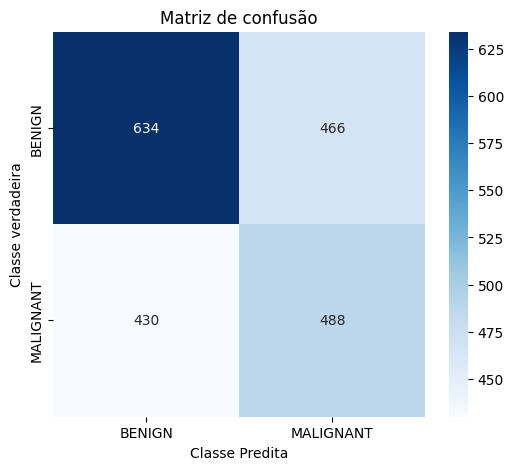

In [38]:
print("\n=== Matriz de Confusão - Árvore de Decisão ===")
plot_confusion_matrix(cm_dt, class_names=['BENIGN', 'MALIGNANT'])

Essa matriz de confusão da Árvore de Decisão mostra:

634 casos de BENIGN que foram corretamente classificados como BENIGN (verdadeiros negativos).
466 casos de BENIGN que foram classificados incorretamente como MALIGNANT (falsos positivos).
430 casos de MALIGNANT classificados como BENIGN (falsos negativos).
488 casos de MALIGNANT corretamente classificados como MALIGNANT (verdadeiros positivos).

O modelo parece ter dificuldades tanto em identificar corretamente os malignos quanto em não confundir benignos como malignos.


=== Matriz de Confusão - MLP ===


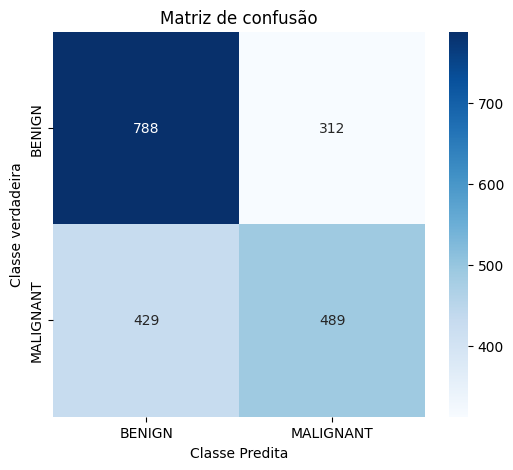

In [39]:
print("\n=== Matriz de Confusão - MLP ===")
plot_confusion_matrix(cm_mlp, class_names=['BENIGN', 'MALIGNANT'])

Aqui o que ela mostra:

788 casos de BENIGN corretamente classificados como BENIGN.
312 casos de BENIGN incorretamente classificados como MALIGNANT.
429 casos de MALIGNANT classificados como BENIGN.
489 casos de MALIGNANT corretamente classificados como MALIGNANT.

Aqui percebemos que o MLP apresentou melhor desempenho quando comparado à arvore de decisão pois tem uma menor taxa de falsos positivos e verdadeiros negativos.

In [40]:
# Função para calcular e exibir a curva ROC
def plot_roc_curve(fpr, tpr, auc_score):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()

In [41]:
fpr_dt, tpr_dt, _ = roc_curve(y_numeric, y_pred_dt)
fpr_mlp, tpr_mlp, _ = roc_curve(y_numeric, y_pred_mlp)

auc_dt = auc(fpr_dt, tpr_dt)
auc_mlp = auc(fpr_mlp, tpr_mlp)

Plotando as Curvas roc


=== Curva ROC - Árvore de Decisão ===


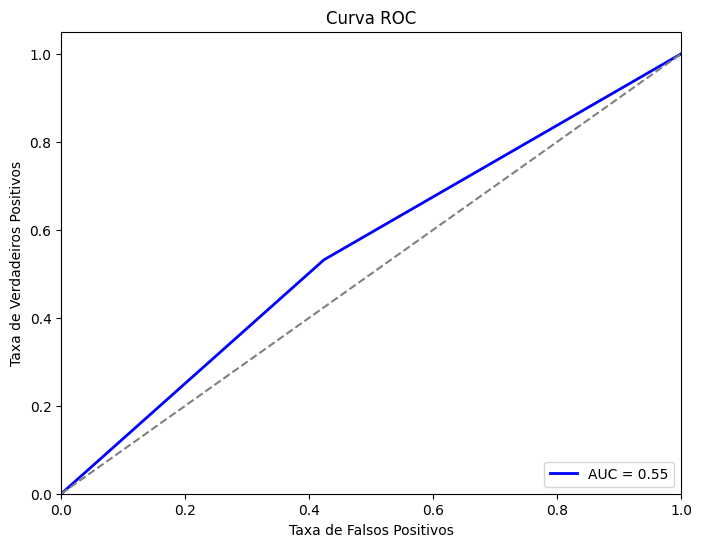

In [42]:

print("\n=== Curva ROC - Árvore de Decisão ===")
plot_roc_curve(fpr_dt, tpr_dt, auc_dt)

Aqui verificamos que a AUC está bem próximo de 0.5 ou seja a árvore de decisão está basicamente chutando.
O modelo não está muito melhor que o acaso. 


=== Curva ROC - MLP ===


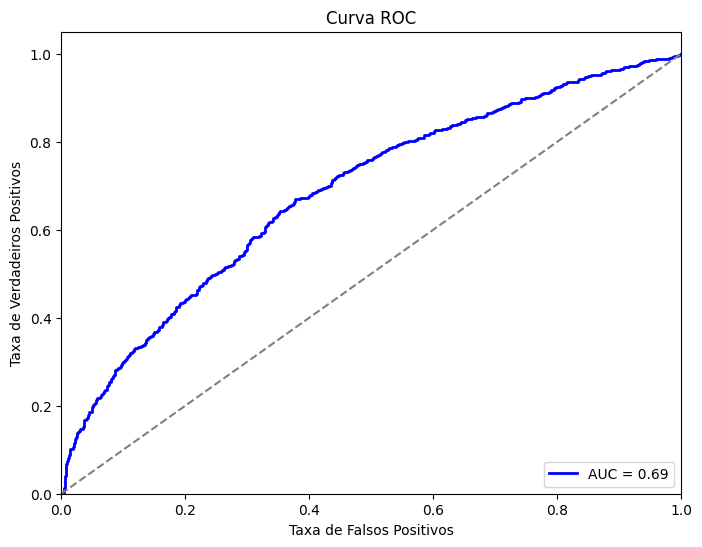

In [47]:
print("\n=== Curva ROC - MLP ===")
plot_roc_curve(fpr_mlp, tpr_mlp, auc_mlp)


Aqui verificamos que o valor da AUC é de 0,69 ou seja ele é bem melhor do que o acaso 

Exibindo os F1-scores

In [44]:

print(f"\nF1-Score Árvore de Decisão: {f1_dt:.4f}")
print(f"F1-Score MLP: {f1_mlp:.4f}")

# Comparando os resultados
if f1_dt > f1_mlp:
    print("\nA Árvore de Decisão tem o melhor F1-Score.")
else:
    print("\nO MLP tem o melhor F1-Score.")

if auc_dt > auc_mlp:
    print("\nA Árvore de Decisão tem a melhor AUC.")
else:
    print("\nO MLP tem a melhor AUC.")


F1-Score Árvore de Decisão: 0.5566
F1-Score MLP: 0.6296

O MLP tem o melhor F1-Score.

O MLP tem a melhor AUC.


### 1.3.1 Comparação dos desempenhos dos algoritmos

Nesta análise vamos comparar o desempenho usando os Algoritmos de Árvore de decisão e MLP. Utilizou-se 3 métricas: F1 Score,
Curva ROC e Matriz de confusão.
Em relação ao F1-Score, que avalia o equilíbrio entre precisão e revocação, os resultados obtidos foram: 
- Árvore de Decisão: F1 Score de 0,5566
- MLP: F1 score de 0,6296


O MLP apresentou um F1-Score Superior indicando que há uma maior capaciada de acertar classificações positivas sem comprometer a precisão geral
Quanto a análise da curva ROC observou-se que:
- A Árvore de decisão obteve um valor de AUC de 0,55 indicando apenas uma pouca melhora que o acaso
- O MLP alcançou um AUC de 0,69 evidenciando uma melhoria na capacidade de distinção entre classes positivas e classes negativas

Analisando a matriz de confusão, também percebe-se que essas conclusões são reforçadas
Observamos que:
-  A matriz de confusão da árvore de decisão apresentou uma quantidade elevada de falsos positivos e falsos negativos, o que comprometeu tanto a revocação quanto a precisão do modelo
-  Por outro lado, a matriz de confusão MLP demonstro uma maior concentração de verdadeiros positivos e verdadeiros negativos, com redução de erros de classificação refletiu-se então em um desempenho mais consistente

Portanto, considerando o conjunto de métricas analisadas, o MLP demonstrou desempenho superior ao modelo de Árvore de decisão, apresentando melhor capacidade preditiva, melhor separação entre as classes e um balanço mais eficiente entre precisão e revocação 

### 2.0 Analise de Agrupamento

Com base nos dados que conseguimos nas seções anteriores o próximo passo é fazer uma análise de agrupamento, clustering, para identificar padrões sem supervisão 

### 2.1 Algoritmos K-Means e Hierárquico

In [50]:
X_clustering = X_scaled
X_clustering

array([[ 0.49285724, -0.20220057, -0.60266027, ..., -0.24894554,
         0.85040593, -0.62984639],
       [-1.97387377, -0.89544039, -1.12566717, ...,  3.14123422,
         3.39834177,  0.20425061],
       [ 0.8782944 ,  1.3905267 ,  0.12576008, ..., -0.70247872,
        -0.49351159,  0.45132306],
       ...,
       [ 0.13374665,  1.2134082 ,  1.40930262, ...,  0.04599727,
        -0.27862903, -0.01622664],
       [-0.32975574, -0.97998184, -0.64606181, ..., -0.13904155,
         0.03403467, -0.48240778],
       [ 0.02216209,  0.49355038,  1.89211235, ..., -0.51933429,
        -0.44084439, -0.05439526]])

Vamos trabalhar com dados já normalizados, por isso definimos X_clustering como sendo nossa variavel X_scaled.
Como K-means e Hierarquico são sensívels à escala das variáveis, temos que usar dessa maneira 

In [53]:
k_means = KMeans(n_clusters=2, random_state=42)
kmeans_labels = k_means.fit_predict(X_clustering)

Agora escolhemos 2 clusters para tentar refletir a estrutura original dos dados, mesmo que os rótulos não estejam disponiveis, fixamos random_state=42 para garantir a reprodutibilidade dos dados. 

In [61]:
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_labels = hierarchical.fit_predict(X_clustering)

O Algoritmo hierarquico é baseado em distâncias, e, assim como o K-Means, usamos 2 clusters para manter a coerência comparativa

In [62]:
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_clustering)

Como o conjunto de dados original tem alta dimensionalidade, aqui vamos usar apenas 2 componentes 
para visualizar melhor os agrupamentos em um gráfico 2D

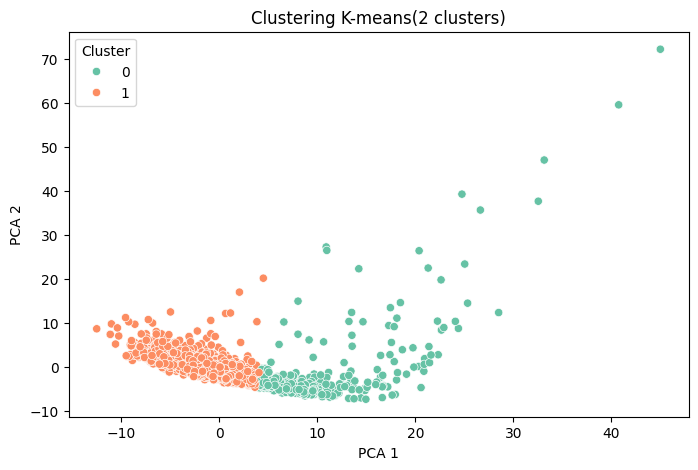

In [63]:
# Visualizando os clusters gerados pelo K-Means

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:,1], hue=kmeans_labels, palette='Set2')
plt.title("Clustering K-means(2 clusters)")
plt.xlabel("PCA 1")
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.show()

O scatter plot mostra como o algoritmo separou os dados após a redução para 2 dimensões, colorindo os clusters encontrados
pelo K-Means

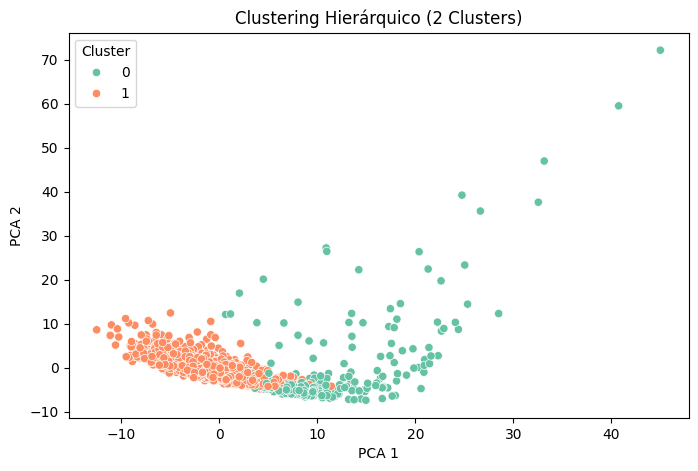

In [64]:
# Visualizando os clusters gerados pelo Hierárquico
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:,1], hue=hierarchical_labels, palette='Set2')
plt.title("Clustering Hierárquico (2 Clusters)")
plt.xlabel("PCA 1")
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.show()

Fazemos agora uma segunda visualização, dessa vez para o agrupamento hierárquico, para comparar se os clusters ficaram
mais separados os misturados. 

In [69]:
silhouette_kmeans = silhouette_score(X_clustering, kmeans_labels)
silhouette_hierarchical = silhouette_score(X_clustering, hierarchical_labels)

print(f"Silhouette Score - K-Means: {silhouette_kmeans:.4f}")
print(f"Silhouette Score - Hierárquico: {silhouette_hierarchical:.4f}")

Silhouette Score - K-Means: 0.4332
Silhouette Score - Hierárquico: 0.4533


Agora vamos avaliar a qualidade do modelo usando o Silhouette Score, medindo quão bem as instãncias estão agrupadas.
Variando de -1 até 1.
Valores próximos de 1 indicam que os objetos estão bem agrupados e separados de outros clusters 
Valores próximos de 0 indicam que os objetos estão muito próximos na fronteira entre clusters.
Valores negativos indicam agrupamentos incorretos. 
O valor obtido para ambos os métodos está na faixa moderada, entre 0.4 e 0.5,  indicando que os agrupamentos não são perfeitamente bem
definidos, mas ainda assim apresentam uma separação razoável entre clusters. 

Comparativamente o hierárquico apresentou um desempenho superior em relação ao K-Means(hierárquico com um valor de 0.4533 e k-means com um 
valor de 0.4332) sugerindo que para esse conjunto de dados a abordagem 
hierárquica conseguiu formar agrupamentos um poucos mais coesos internamente e mais separados entre si do que o método k-means. 


### 2.2 Método do cotovelo

Vamos utilizar o método do cotovelo para determinar o número ideal de clusters para o K-means.
Basicamente o que iremos fazer é calcular a soma dos erros quadraticos internos para diferentes valores de k e observar
o ponto onde ocorre uma diminuição mais abrupta na curva, sugerindo um número ótimo de agrupamentos. 

In [72]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

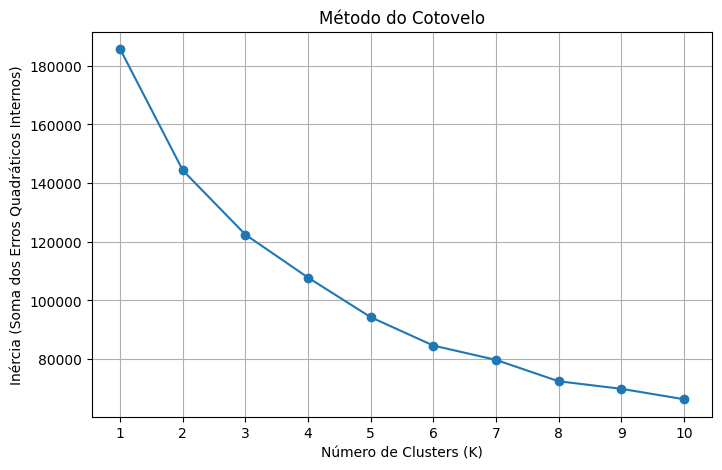

In [73]:
inertia = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_values, inertia, marker="o")
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos Erros Quadráticos Internos)')
plt.xticks(K_values)
plt.grid(True)
plt.show()

Com base no gráfico acima, pelo fato da redução da inércia ter sido maior entre k=1 e k=2, e também por que a redução tornase menos expressiva 
após esse valor, conseguimos determinar que o melhor valor para K é 2.

### 2.3 Comparando resultados entre K-Means e hierárquico com o valor de k obtido

Vamos rodar novamente os algoritmos com k=2

In [76]:
# K-Means com K=2
kmeans_final = KMeans(n_clusters=2, random_state=42)
kmeans_labels_final = kmeans_final.fit_predict(X_clustering)

# Hierárquico com K=2
hierarchical_final = AgglomerativeClustering(n_clusters=2)
hierarchical_labels_final = hierarchical_final.fit_predict(X_clustering)

In [77]:
# Avaliando a qualidade dos agrupamentos
silhouette_kmeans_final = silhouette_score(X_clustering, kmeans_labels_final)
silhouette_hierarchical_final = silhouette_score(X_clustering, hierarchical_labels_final)

print(f"Silhouette Score (K-Means): {silhouette_kmeans_final:.4f}")
print(f"Silhouette Score (Hierárquico): {silhouette_hierarchical_final:.4f}")

Silhouette Score (K-Means): 0.4332
Silhouette Score (Hierárquico): 0.4533


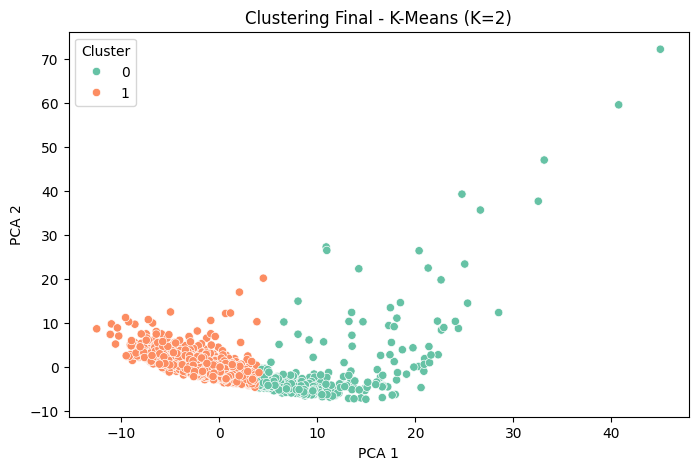

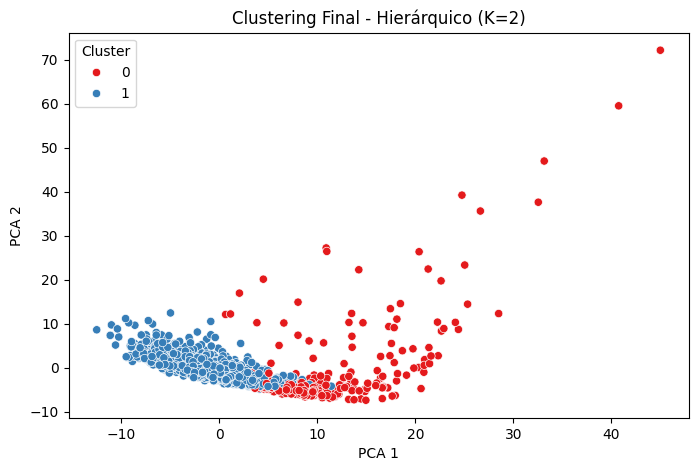

In [78]:
pca = PCA(n_components=2)
X_pca_final = pca.fit_transform(X_clustering)

# Plot K-Means
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=kmeans_labels_final, palette='Set2')
plt.title('Clustering Final - K-Means (K=2)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

# Plot Hierárquico
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=hierarchical_labels_final, palette='Set1')
plt.title('Clustering Final - Hierárquico (K=2)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

Após fazer uma análise quantitativa através do Silhouette Score com k=2 conseguimos determinar o score para o K-Means que é de 0,4332
e o hierárquico que é 0,4533. Conseguimos verificar que como o score no Clustering hierarquico é superior, indica-se que formou-se agrupamentos mais coesos internamente e mais separados entre si. 
Dessa forma, o método hierárquico conseguiu capturar melhor a estrutura natural dos dados sem supervisão. 
Além disso, a visualização dos clusters em duas dimensões via PCA também reforça a separação observada, mostrando uma formação de grupos mais definida no modelo hierárquico.

### 2.4 Usando dois métodos diferentes de Linkage no algoritmo hierárquico

No agrupamento hierárquico, o linkage é definimo como a distância entre os clusters e pode ser calculada de várias formas.
Entre elas temos duas:
- average: Usa a média das distâncias entre todos os pontos de dois clusters
- complete: Usa a maior distância possivel entre pontos de diferentes clusters 
Nos próximos códigos vamos testar o algoritmo hierárquico usando esses dois métodos de linkage


In [82]:
# Hierárquico com linkage = 'complete'
hierarchical_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
labels_complete = hierarchical_complete.fit_predict(X_clustering)
silhouette_complete = silhouette_score(X_clustering, labels_complete)

# Hierárquico com linkage = 'average'
hierarchical_average = AgglomerativeClustering(n_clusters=2, linkage='average')
labels_average = hierarchical_average.fit_predict(X_clustering)
silhouette_average = silhouette_score(X_clustering, labels_average)

# Exibindo os resultados
print(f"Silhouette Score (linkage='complete'): {silhouette_complete:.4f}")
print(f"Silhouette Score (linkage='average'): {silhouette_average:.4f}")


Silhouette Score (linkage='complete'): 0.8337
Silhouette Score (linkage='average'): 0.8744


Vamos agora fazer a visualização de ambos os métodos hierárquicos usando diferentes formas de linkage:

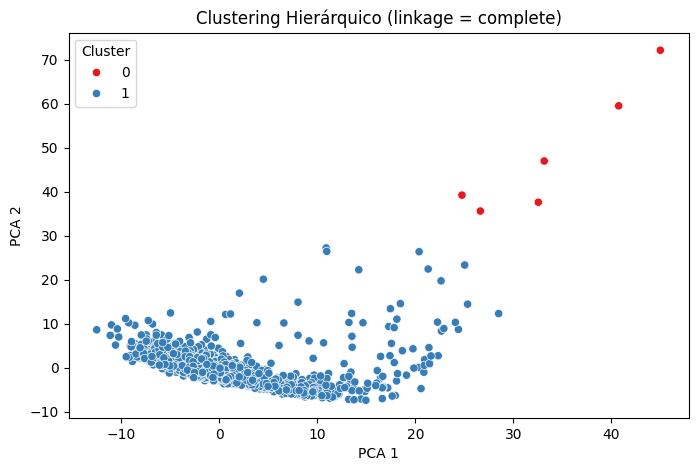

In [83]:
pca = PCA(n_components=2)
X_pca_linkage = pca.fit_transform(X_clustering)

# Visualizando Clustering Complete
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_linkage[:, 0], y=X_pca_linkage[:, 1], hue=labels_complete, palette='Set1')
plt.title('Clustering Hierárquico (linkage = complete)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

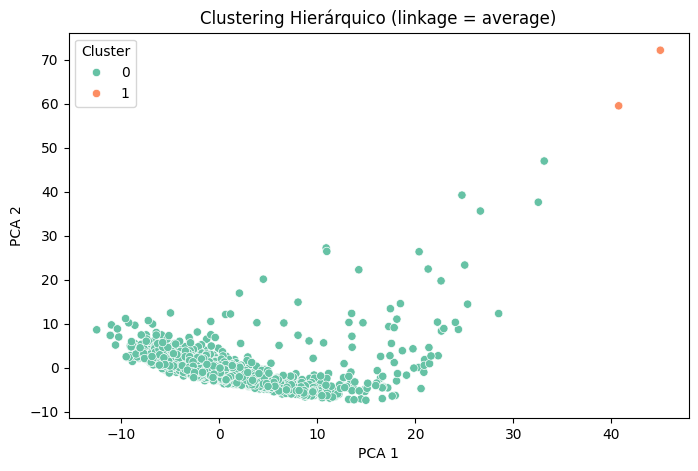

In [86]:
# Visualizando Clustering Average
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_linkage[:, 0], y=X_pca_linkage[:, 1], hue=labels_average, palette='Set2')
plt.title('Clustering Hierárquico (linkage = average)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

Nessa etapa foi realizada a comparadação entre dois metodos de linkage aplicados ao algoritmo de clustering hierárquico: complete e average.
Os resultados obtidos foram:
Linkage = Complete: Silhouette Score de 0,8337
Linkage = Average: Silhouette Score de 0,8744
O método de linkage average apresentou o maior Silhouette Score, indicando que os agrupamentos formados por essa abordagem foram mais coesos internamente e melhor separados entre os clusters, em comparação com o método complete.
A diferença observada sugere que o linkage average conseguiu capturar melhor a estrutura dos dados, gerando agrupamentos mais naturais e consistentes.

### 3.5 Comparando resultados das técnicas de clustering usando métricas adequadas

Vamos comparar os resultados das diferentes técnicas de clustering aplicadas ao conjunto de dados usando como métrica principal o
Silhouette Score. Essa métrica foi escolhida por ser mais apropriada em cenários de aprendizado não supervisionado, uma vez que avalia a coesão intra-cluster e a separação inter-cluster sem a necessidade de rótulos conhecidos.

O silhouette score obtido para o algoritmo k-means foi de 0,4332, indicando uma formação de clusters moderada, com
alguma sobreposição de grupos

O clusterting hierárquico com linkage 'ward' apresentou desempenho de 0,4533 mas ainda dentro de uma faixa de separação razoável.

Quando outros métodos de linkage foram testados:
    - O linkage 'complete' mostrou uma melhora significativa com valor de 0,8337 evidenciando clusters bem formados e separados
    - O linkage 'average' mostrou um melhor desempenho geral, com um silhouette score de 0,8744, indicando também agrupamentos altamente coesos e excelente separação.

Visualmente, ao reduzir os dados para duas dimensões usando PCA, os clusteers formados com linkage "avarage" mostraram-se mais compactos e bem definidos em comparação com as demais abordagens. 

A utilização do silhouette score é justificada pela natureza do problema: como clustering é não supervisionado não há rótulos verdadeiros para comparação direta. 
O Silhouette score fornece uma medida objetiva de qualidade dos agrupamentos com base apenas nas distâncias internas e externas aos clusters.


Agora vamos utilizar outras 2 métricas para clustering sem supervisão:
- Calinski-Harabasz Index (CHI): Mede a razão entre dispersão intra-cluster e inter-cluster (quanto maior, melhor).

- Davies-Bouldin Index (DBI): Mede a média das similaridades entre clusters (quanto menor, melhor).

In [89]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, name="Algoritmo"):
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    print(f"Resultados para {name}:")
    print(f" - Calinski-Harabasz Index: {calinski:.4f}")
    print(f" - Davies-Bouldin Index: {davies:.4f}")
    print()

evaluate_clustering(X_clustering, kmeans_labels_final, name="K-Means (k=2)")
evaluate_clustering(X_clustering, hierarchical_labels_final, name="Hierárquico (ward)")
evaluate_clustering(X_clustering, labels_complete, name="Hierárquico (complete)")
evaluate_clustering(X_clustering, labels_average, name="Hierárquico (average)")

Resultados para K-Means (k=2):
 - Calinski-Harabasz Index: 576.9442
 - Davies-Bouldin Index: 1.3674

Resultados para Hierárquico (ward):
 - Calinski-Harabasz Index: 530.4390
 - Davies-Bouldin Index: 1.4115

Resultados para Hierárquico (complete):
 - Calinski-Harabasz Index: 299.8957
 - Davies-Bouldin Index: 0.5000

Resultados para Hierárquico (average):
 - Calinski-Harabasz Index: 186.4049
 - Davies-Bouldin Index: 0.1804



Analisando os resultados para o Calinski-Harabasz Index (CHI):
- O K-Means(k=2) apresentou maior valor de CHI, 576.9442, indicando que os clusteram foram mais dispersos entre si, o que é
o esperado.
- O Hierárquico Ward ficou próximo com 530.4390 também indicando boa separação
- Os métodos hierárquico complete e average apresentaram valores mais baixos de CHI, indicando clusters mais próximos ou menos espalhados

Analisandos os resultados do Davies-Bouldin Index(DBI):
- O Hierarquico com linkage "average" obteve o menor DBI com valor de 0.1804, indicando clusters mais compactos e separados, o que é ideal.
- O Hierárquico com linkage "complete" também teve um bom desempenho nesse aspecto, com 0.5
- Em contrapartida o K-means e o hierarquico ward tiveram DBI elevados, acima de 1, indicando que os clusters gerados estão mais próximos e possivelmente sobrepostos. 

Essas métricas foram escolhidas pois fornecem uma avaliação independente da necessidade de rótulos:
- O CHI mede a separação global dos agrupamentos com base na relação entre a variância entre clusters e a variância dentro dos clusters
- O DBI mede a compacidade dos clusters, penalizando agrupamentos com sobreposição errada.
Tais métricas complementam-se e fornecem uma visão ampla sobre a qualidade dos agrupamentos.


Considerando apenas o CHI o k-means com k=2 apresentou o melhor desempenho, indicando clusters mais dispersos e separados.
No entanto, ao considerar o DBI o hierárquico com linkage "average" se destaca como método que formou clusters mais compactos e 
com menor sobreposição.